# Demo for the ProblemsSolvers class.

This script is intended to help with debugging problems and solvers.

It create problem-solver groups (using the directory) and runs multiple macroreplications of each problem-solver pair.

## Append SimOpt Path

Since the notebook is stored in simopt/notebooks, we need to append the parent simopt directory to the system path to import the necessary modules later on.

In [18]:
import sys
from pathlib import Path

import random 
import numpy as np 

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

## Configuration Parameters

This section defines the core parameters for the demo.

To query model/problem/solver names, run `python scripts/list_directories.py`

In [8]:
# Specify the names of the solver(s) and problem(s) to test.
solver_abbr_names = ["ASTROMORF", "ASTRODF", "STRONG", "ADAM", "RNDSRCH", "NELDMD"] #add NELDMD once fixed
solver_full_names = {"STRONG": "STRONG", "ASTROMORF": "ASTROMoRF", "ASTRODF": "ASTRO-DF", "ADAM": "ADAM", "RNDSRCH": "RANDOM SEARCH", "NELDMD": "NELDER-MEAD"}

problem_abbr_names =  ["FACSIZE-1", "DYNAMNEWS-1", "CONTAM-2", "ROSENBROCK-1", "NETWORK-1"]
num_macroreps = 10
budget = 10000
num_postreps = 50  
num_postreps_init_opt = 50

In [10]:
def update_model_factors_dimensions(problem_name: str, new_dim: int) -> dict:
	"""
		Find the model associated with model_name and update the dimension of the factor values to the new_dim.
		Return the updated model factors.

	Args:
		model_name (str): Name of Model
		new_dim (int): New dimension for the model

	Returns:
		dict: Updated model factors
	"""
	new_factors = {}
	if problem_name == 'DYNAMNEWS-1':
		new_factors= {
			'num_prod': new_dim,
			'c_utility': [6 + j for j in range(new_dim)],
			'init_level': [3] * new_dim,
			'price': [9] * new_dim,
			'cost': [5] * new_dim,
		}
	elif problem_name == 'FACSIZE-1' or problem_name == 'FACSIZE-2':
		# Create a valid positive semi-definite covariance matrix
		A = np.random.randint(1, 10, size=(new_dim, new_dim))
		cov_matrix = np.dot(A, A.T)  # Ensures positive semi-definite
		# NOTE: 'capacity' is a decision variable but must be included with correct
		# dimension for model validation. It will be overwritten by the solver.
		new_factors= {
			'mean_vec': [500] * new_dim,
			'cov': cov_matrix.tolist(),
			'capacity': [300] * new_dim,  # Placeholder - solver will overwrite via initial_solution
			'n_fac': new_dim,
		}
	elif problem_name == 'FIXEDSAN-1':
		new_factors= {
			'num_arcs': new_dim,
			'num_nodes': np.random.randint(1, new_dim),
			'arc_means': tuple([np.random.randint(1, 20) for _ in range(new_dim)]),
		}
	elif problem_name == 'AIRLINE-1' or problem_name == 'AIRLINE-2':
		num_classes = random.randint(2, new_dim // 2)
		odf_leg_matrix = np.random.randint(0, 2, (new_dim, num_classes))
		new_factors= {
			'num_classes': num_classes,
			'ODF_leg_matrix': odf_leg_matrix.tolist(),
			'prices': tuple([random.randint(50, 300) for _ in range(new_dim)]),
			'capacity': tuple([random.randint(20, 150) for _ in range(num_classes)]),
			'booking limits': tuple([random.randint(5, 20) for _ in range(new_dim)]),
			'alpha': tuple([random.uniform(0, 5) for _ in range(new_dim)]),
			'beta':  tuple([random.uniform(2, 10) for _ in range(new_dim)]),
			'gamma_shape': tuple([random.uniform(2, 10) for _ in range(new_dim)]),
			'gamma_scale': tuple([random.uniform(10, 50) for _ in range(new_dim)]),
		}
	elif problem_name == 'NETWORK-1':
		# NOTE: 'process_prob' is a decision variable but must be included with correct
		# dimension for model validation. It will be overwritten by the solver.
		mode_transit_time = [round(np.random.uniform(0.01, 5), 3) for _ in range(new_dim)]
		lower_limits_transit_time = [x / 2 for x in mode_transit_time] 
		upper_limits_transit_time = [2 * x for x in mode_transit_time]
		new_factors= {
			'process_prob': [1/new_dim] * new_dim,  # Placeholder - solver will overwrite
			'cost_process': [0.1 / (x + 1) for x in range(new_dim)],
			'cost_time': [round(np.random.uniform(0.01, 1), 3) for _ in range(new_dim)],
			'mode_transit_time': mode_transit_time,
			'lower_limits_transit_time': lower_limits_transit_time,
			'upper_limits_transit_time': upper_limits_transit_time,
			'n_networks': new_dim,
		}
	elif problem_name == 'CONTAM-2':
		# NOTE: 'prev_decision' is a decision variable but must be included with correct
		# dimension for model validation. It will be overwritten by the solver.
		new_factors= {
			'stages': new_dim,
			'prev_decision': (0.5,) * new_dim,  # Placeholder - solver will overwrite
		}
	elif problem_name == 'ROSENBROCK-1':
		# NOTE: 'x' is a decision variable but must be included with correct
		# dimension for model validation. It will be overwritten by the solver.
		new_factors = {
			'x': (2.0,) * new_dim,  # Placeholder - solver will overwrite
		}
	
	return new_factors


def update_problem_factor_dimensions(problem_name: str, new_dim: int, budget: int) -> dict:
	"""
		Update the dimension of the factor values in problem_factors to the new_dim.
		Return the updated problem factors.

	Args:
		problem_factors (dict): Problem factors to be updated
		new_dim (int): New dimension for the problem factors

	Returns:
		dict: Updated problem factors
	"""
	new_factors = {}
	if problem_name == 'DYNAMNEWS-1':
		new_factors = {
			'initial_solution': (3,) * new_dim,
			'budget': budget,
		}
	elif problem_name == 'FACSIZE-1':
		new_factors = {
			'initial_solution': (100,) * new_dim,
			'installation_costs': (1,) * new_dim,
			'epsilon': 0.05,
			'budget': budget,
		}
	elif problem_name == 'FACSIZE-2':
		new_factors = {
			'initial_solution': (300,) * new_dim,
			'installation_costs': (1,) * new_dim,
			'installation_budget': 500.0,
			'budget': budget,
		}
	elif problem_name == 'FIXEDSAN-1': 
		new_factors = {
			'budget': budget,
		}
	elif problem_name == 'AIRLINE-1' or problem_name == 'AIRLINE-2':
		new_factors = {
			'initial_solution': (3,) * new_dim,
			'budget': budget,
		}
	elif problem_name == 'NETWORK-1':
		# Initial solution must sum to 1 (routing probabilities)
		init_soln_elem = 1 / new_dim
		new_factors = {
			'initial_solution': (init_soln_elem,) * new_dim,
			'budget': budget,
		}
	elif problem_name == 'CONTAM-2':
		new_factors = {
			'initial_solution': (0.5,) * new_dim,  # Values between 0 and 1
			'prev_cost': [1] * new_dim,
			'error_prob': [0.2] * new_dim,
			'upper_thres': [0.1] * new_dim,
			'budget': budget,
		}
	elif problem_name == 'ROSENBROCK-1':
		# Rosenbrock problem: initial solution should be within bounds [-5, 10]
		# Starting at (2, 2, ..., 2) is a reasonable choice
		new_factors = {
			'initial_solution': (2.0,) * new_dim,
			'budget': budget,
		}
	return new_factors

In [11]:

from simopt.experiment_base import instantiate_problem, instantiate_solver, ProblemSolver
from simopt.solvers.astromorf import PolyBasisType
#Create Solver and Problem instances
new_dim = 50 

#! NEED TO UPDATE - EVERYTHING BUT NETWORK-1 
ASTROMoRF_subspace_degree: dict = {
    'DYNAMNEWS-1': {'initial subspace dimension': 1, 'polynomial degree': 4, 'polynomial basis': PolyBasisType.HERMITE},
    'NETWORK-1': {'initial subspace dimension': 1, 'polynomial degree': 2, 'polynomial basis': PolyBasisType.HERMITE},
    'FACSIZE-1': {'initial subspace dimension': 1, 'polynomial degree': 4, 'polynomial basis': PolyBasisType.HERMITE},
    'FACSIZE-2': {'initial subspace dimension': 1, 'polynomial degree': 4,'polynomial basis': PolyBasisType.HERMITE},
    'CONTAM-2': {'initial subspace dimension': 1, 'polynomial degree': 4, 'polynomial basis': PolyBasisType.HERMITE},
    'ROSENBROCK-1': {'initial subspace dimension': 1, 'polynomial degree': 4, 'polynomial basis': PolyBasisType.HERMITE},
}

problem_solvers = [[ProblemSolver(problem_name = problem, solver_name = solver, solver_rename=solver_full_names[solver], problem_fixed_factors=update_problem_factor_dimensions(problem, new_dim, budget), model_fixed_factors=update_model_factors_dimensions(problem, new_dim)) for problem in problem_abbr_names] for solver in solver_abbr_names if solver != 'ASTROMORF']

#create astromorf problem solvers with updated factors
astromorf_problem_solvers = []
for problem in problem_abbr_names:
    solver_factors = ASTROMoRF_subspace_degree[problem]
    ps = ProblemSolver(problem_name = problem, solver_name = 'ASTROMORF', solver_rename='ASTROMoRF', solver_fixed_factors=solver_factors, model_fixed_factors=update_model_factors_dimensions(problem, new_dim), problem_fixed_factors=update_problem_factor_dimensions(problem, new_dim, budget))
    astromorf_problem_solvers.append(ps)

problem_solvers.append(astromorf_problem_solvers)

for ps in problem_solvers : 
    for p in ps : 
        print(p.solver.name, p.problem.name)

ASTRO-DF FACSIZE-1
ASTRO-DF DYNAMNEWS-1
ASTRO-DF CONTAM-2
ASTRO-DF ROSENBROCK-1
ASTRO-DF NETWORK-1
STRONG FACSIZE-1
STRONG DYNAMNEWS-1
STRONG CONTAM-2
STRONG ROSENBROCK-1
STRONG NETWORK-1
ADAM FACSIZE-1
ADAM DYNAMNEWS-1
ADAM CONTAM-2
ADAM ROSENBROCK-1
ADAM NETWORK-1
RANDOM SEARCH FACSIZE-1
RANDOM SEARCH DYNAMNEWS-1
RANDOM SEARCH CONTAM-2
RANDOM SEARCH ROSENBROCK-1
RANDOM SEARCH NETWORK-1
NELDER-MEAD FACSIZE-1
NELDER-MEAD DYNAMNEWS-1
NELDER-MEAD CONTAM-2
NELDER-MEAD ROSENBROCK-1
NELDER-MEAD NETWORK-1
ASTROMoRF FACSIZE-1
ASTROMoRF DYNAMNEWS-1
ASTROMoRF CONTAM-2
ASTROMoRF ROSENBROCK-1
ASTROMoRF NETWORK-1


In [12]:
# Initialize an instance \of the experiment class.
from simopt.experiment_base import ProblemsSolvers

mymetaexperiment = ProblemsSolvers(experiments=problem_solvers, file_name_path='poster_solvability.pickle')


for experiment in mymetaexperiment.experiments : 
    print(f'SOLVER: {experiment[0].solver.name}')
    for ps in experiment :
        print(f'Running experiment: Problem = {ps.problem.name}, Solver = {ps.solver.name}')
    

# Write to log file. 
mymetaexperiment.log_group_experiment_results()

SOLVER: ASTRO-DF
Running experiment: Problem = FACSIZE-1, Solver = ASTRO-DF
Running experiment: Problem = DYNAMNEWS-1, Solver = ASTRO-DF
Running experiment: Problem = CONTAM-2, Solver = ASTRO-DF
Running experiment: Problem = ROSENBROCK-1, Solver = ASTRO-DF
Running experiment: Problem = NETWORK-1, Solver = ASTRO-DF
SOLVER: STRONG
Running experiment: Problem = FACSIZE-1, Solver = STRONG
Running experiment: Problem = DYNAMNEWS-1, Solver = STRONG
Running experiment: Problem = CONTAM-2, Solver = STRONG
Running experiment: Problem = ROSENBROCK-1, Solver = STRONG
Running experiment: Problem = NETWORK-1, Solver = STRONG
SOLVER: ADAM
Running experiment: Problem = FACSIZE-1, Solver = ADAM
Running experiment: Problem = DYNAMNEWS-1, Solver = ADAM
Running experiment: Problem = CONTAM-2, Solver = ADAM
Running experiment: Problem = ROSENBROCK-1, Solver = ADAM
Running experiment: Problem = NETWORK-1, Solver = ADAM
SOLVER: RANDOM SEARCH
Running experiment: Problem = FACSIZE-1, Solver = RANDOM SEARCH
Ru

In [23]:
# Run a fixed number of macroreplications of each solver on each problem.
mymetaexperiment.run(n_macroreps=num_macroreps)

Solver terminated on FACSIZE-1 after 416 iterations
Solver terminated on FACSIZE-1 after 416 iterations
Solver terminated on FACSIZE-1 after 416 iterations
Solver terminated on FACSIZE-1 after 416 iterations
Solver terminated on FACSIZE-1 after 416 iterations
Solver terminated on FACSIZE-1 after 416 iterations
Solver terminated on FACSIZE-1 after 416 iterations
Solver terminated on FACSIZE-1 after 416 iterations
Solver terminated on FACSIZE-1 after 416 iterations
Solver terminated on FACSIZE-1 after 416 iterations
Finished running ASTRO-DF on FACSIZE-1 in 12.028 seconds over 10 mreps.
Writing function estimate and budget history data to CSV files...
Solver terminated on DYNAMNEWS-1 after 5 iterations
Solver terminated on DYNAMNEWS-1 after 5 iterations
Solver terminated on DYNAMNEWS-1 after 5 iterations
Solver terminated on DYNAMNEWS-1 after 5 iterations
Solver terminated on DYNAMNEWS-1 after 5 iterations
Solver terminated on DYNAMNEWS-1 after 5 iterations
Solver terminated on DYNAMNEWS

Finished running STRONG on CONTAM-2 in 17.534 seconds over 10 mreps.
Finished running STRONG on ROSENBROCK-1 in 1.081 seconds over 10 mreps.


Finished running STRONG on NETWORK-1 in 203.05 seconds over 10 mreps.
Finished running ADAM on FACSIZE-1 in 2.505 seconds over 10 mreps.
Finished running ADAM on DYNAMNEWS-1 in 29.206 seconds over 10 mreps.
Finished running ADAM on CONTAM-2 in 5.693 seconds over 10 mreps.
Finished running ADAM on ROSENBROCK-1 in 2.199 seconds over 10 mreps.
Finished running ADAM on NETWORK-1 in 43.611 seconds over 10 mreps.
Finished running RANDOM SEARCH on FACSIZE-1 in 3.847 seconds over 10 mreps.
Finished running RANDOM SEARCH on DYNAMNEWS-1 in 37.578 seconds over 10 mreps.
Finished running RANDOM SEARCH on CONTAM-2 in 7.016 seconds over 10 mreps.
Finished running RANDOM SEARCH on ROSENBROCK-1 in 0.498 seconds over 10 mreps.
Finished running RANDOM SEARCH on NETWORK-1 in 49.905 seconds over 10 mreps.
Finished running NELDER-MEAD on FACSIZE-1 in 2.897 seconds over 10 mreps.
Finished running NELDER-MEAD on DYNAMNEWS-1 in 37.183 seconds over 10 mreps.
Finished running NELDER-MEAD on CONTAM-2 in 6.198 se

In [24]:
print("Post-processing results.")
# Run a fixed number of postreplications at all recommended solutions.
mymetaexperiment.post_replicate(n_postreps=num_postreps)

Post-processing results.
Finished Postreplications for ASTRO-DF on FACSIZE-1
Finished Postreplications for ASTRO-DF on DYNAMNEWS-1
Finished Postreplications for ASTRO-DF on CONTAM-2
Finished Postreplications for ASTRO-DF on ROSENBROCK-1
Finished Postreplications for ASTRO-DF on NETWORK-1
Finished Postreplications for STRONG on FACSIZE-1
Finished Postreplications for STRONG on DYNAMNEWS-1
Finished Postreplications for STRONG on CONTAM-2
Finished Postreplications for STRONG on ROSENBROCK-1
Finished Postreplications for STRONG on NETWORK-1
Finished Postreplications for ADAM on FACSIZE-1
Finished Postreplications for ADAM on DYNAMNEWS-1
Finished Postreplications for ADAM on CONTAM-2
Finished Postreplications for ADAM on ROSENBROCK-1
Finished Postreplications for ADAM on NETWORK-1
Finished Postreplications for RANDOM SEARCH on FACSIZE-1
Finished Postreplications for RANDOM SEARCH on DYNAMNEWS-1
Finished Postreplications for RANDOM SEARCH on CONTAM-2
Finished Postreplications for RANDOM SEAR

In [25]:
print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
mymetaexperiment.post_normalize(n_postreps_init_opt=num_postreps_init_opt)

Post-normalizing results.


In [26]:
from simopt.base import Solution
from mrg32k3a.mrg32k3a import MRG32k3a

def run_difference_variance(runs):
    # Convert each run into a 2D NumPy array
    runs = [np.array(run) for run in runs]  # shape: (iters, dims)

    # 1. Compute centroid (mean recommended solution) for each run
    centroids = np.array([run.mean(axis=0) for run in runs])
    # shape: (num_runs, dims)

    # 2. Compute variance across runs
    # When there's only 1 run, variance is 0 (not NaN)
    if len(centroids) == 1:
        variance_across_runs = np.zeros(centroids.shape[1])
        avg_variance = 0.0
    else:
        variance_across_runs = np.var(centroids, axis=0, ddof=1)
        # 3. Optional: combine into a single scalar
        avg_variance = variance_across_runs.mean()

    return avg_variance, variance_across_runs, centroids

data_list = [a for x in mymetaexperiment.experiments for a in x]
vars_for_subs = {}

#Summarize results
for exp in data_list : 
    print(f'The number of iterations for solver {exp.solver.name} on problem {exp.problem.name} is: {len(exp.all_recommended_xs[0])}')
    terminal_sols =  [exp.all_recommended_xs[i][-1] for i in range(len(exp.all_recommended_xs))]
    
    # Create new solutions and attach RNGs for simulation
    terminal_sol = []
    for i in range(len(terminal_sols)):
        sol = Solution(tuple(terminal_sols[i]), exp.problem)
        # Create and attach RNGs to the solution
        rng_list = [MRG32k3a(s_ss_sss_index=[i + 1000, ss, 0]) for ss in range(exp.problem.model.n_rngs)]
        sol.attach_rngs(rng_list, copy=True)
        terminal_sol.append(sol)

    [exp.problem.simulate(terminal_sol[i], 750) for i in range(len(terminal_sol))]

    #terminal_sol_and_vals is a list of tuples of the objective function value and corresponding solution
    terminal_sol_and_vals = [(terminal_sol[i].objectives_mean.item(), terminal_sol[i]) for i in range(len(terminal_sol))]

    if exp.problem.minmax[0] == 1 :
        #within terminal_sol_and_vals find the maximum objective value and corresponding solution
        optimal_sol_val =  max(terminal_sol_and_vals, key=lambda x: x[0])
    else : 
        optimal_sol_val =  min(terminal_sol_and_vals, key=lambda x: x[0])


    #Group together all solutions of the same iteration at each macroreplication
    avg_rns, var_across_runs, centroids = run_difference_variance(exp.all_recommended_xs)
    print(f"Average variance (difference across runs):\n {avg_rns}")
    print(f"Variance per dimension:\n {var_across_runs}")
    print(f"Centroids (mean solution per run):\n {centroids}")
    if "ASTROMORF" in exp.solver.name :
        vars_for_subs[exp.solver.factors['initial subspace dimension']] = float(avg_rns)
    

    print(f'Variance of recommended solutions at each iteration for solver {exp.solver.name} on problem {exp.problem.name} is: {float(avg_rns)}')

    print(f'The best solution found by solver {exp.solver.name} on problem {exp.problem.name} is: \n{optimal_sol_val[1].x} \n {optimal_sol_val[0]}')
    print(f'The average objective value over all macroreplications is: {np.mean([terminal_sol_and_vals[i][0] for i in range(len(terminal_sol_and_vals))])}')
    print(' ')



The number of iterations for solver ASTRO-DF on problem FACSIZE-1 is: 131
Average variance (difference across runs):
 0.7322568945223741
Variance per dimension:
 [0.73225689 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689
 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689
 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689
 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689
 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689
 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689
 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689
 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689 0.73225689
 0.73225689 0.73225689]
Centroids (mean solution per run):
 [[39.64140157 39.64140157 39.64140157 39.64140157 39.64140157 39.64140157
  39.64140157 39.64140157 39.64140157 39.64140157 39.64140157 39.64140157
  39.64140157 39.64140157 39.64140157 39.64140157 39.64140157 39.64140157
  39.64140157 39.641

Plotting results...


ZeroDivisionError: division by zero

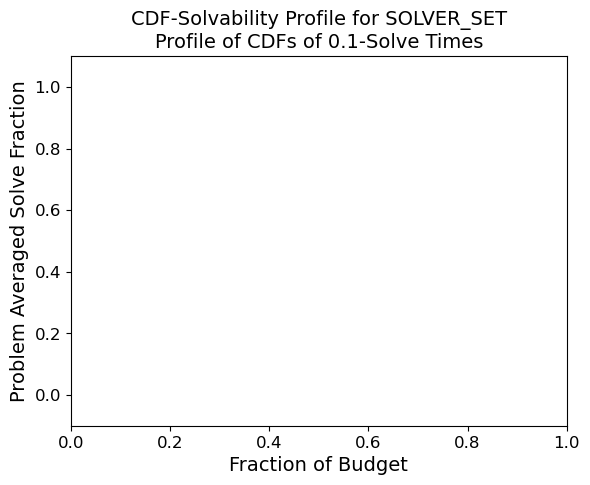

In [13]:
# Produce basic plots.

from simopt.experiment_base import PlotType, plot_solvability_profiles

#Remove NETWORK-1 ProblemSolvers from mymetaexperiment
mymetaexperiment.experiments = [
   [ps for ps in experiment if ps.problem.name != 'NETWORK-1']
   for experiment in mymetaexperiment.experiments
]

print("Plotting results...")

def _print_path(plot_path: list[Path]) -> Path:
    print(f"Plot saved to {plot_path!s}")
    return plot_path[0]


# #remove all FACSIZE-1 ProblemSolvers from mymetaexperiment
# mymetaexperiment.experiments = [
#     [ps for ps in experiment if ps.problem.name != 'FACSIZE-1']
#     for experiment in mymetaexperiment.experiments
# ]


group_plot = _print_path(
    plot_solvability_profiles(
        experiments=mymetaexperiment.experiments, plot_type=PlotType.CDF_SOLVABILITY, solve_tol=0.1, legend_loc='lower right'
    )
)


print("Plotting complete!")

Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-05_17-20-04/plots/SOLVER_SET_FACSIZE-1_mean_prog_curve_unnorm (1).png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-05_17-20-04/plots/SOLVER_SET_DYNAMNEWS-1_mean_prog_curve_unnorm (1).png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-05_17-20-04/plots/SOLVER_SET_CONTAM-2_mean_prog_curve_unnorm (1).png')]
Plot saved to [PosixPath('/Users/benjaminrees/Desktop/simopt/experiments/2025-12-05_17-20-04/plots/SOLVER_SET_ROSENBROCK-1_mean_prog_curve_unnorm (1).png')]


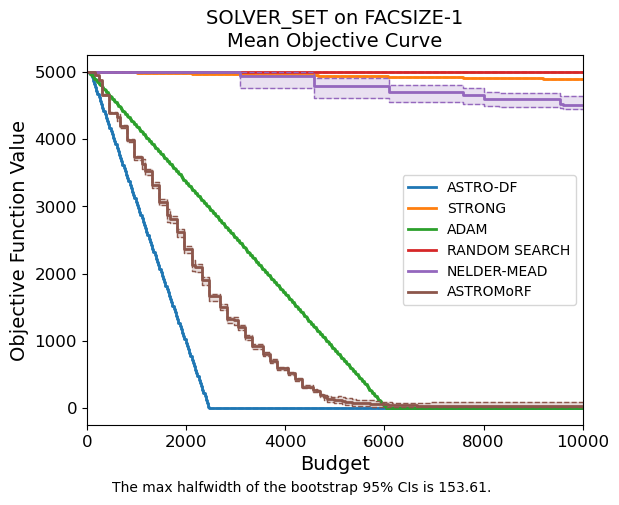

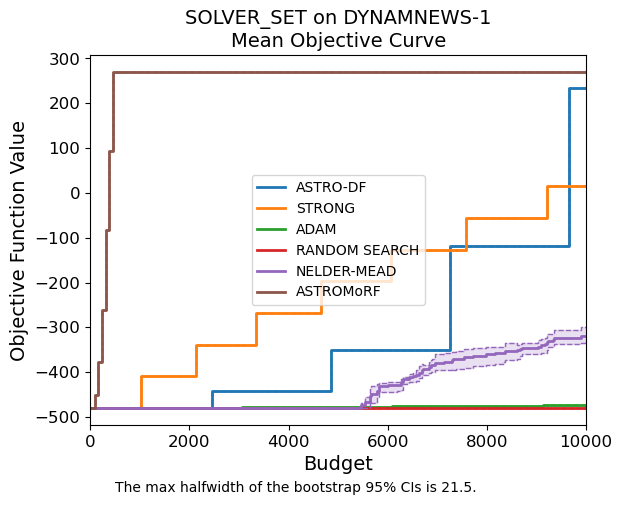

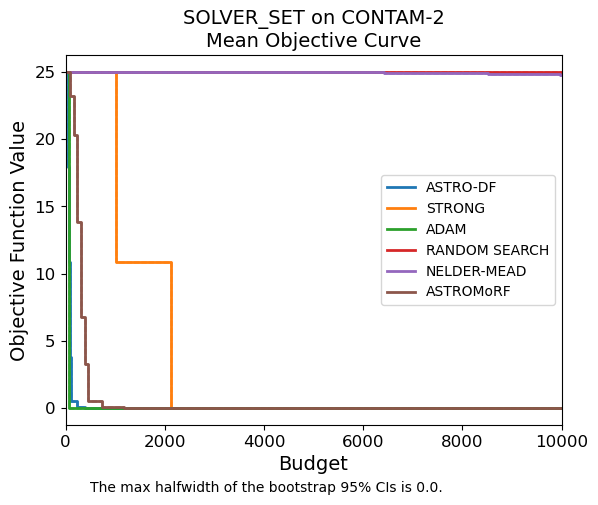

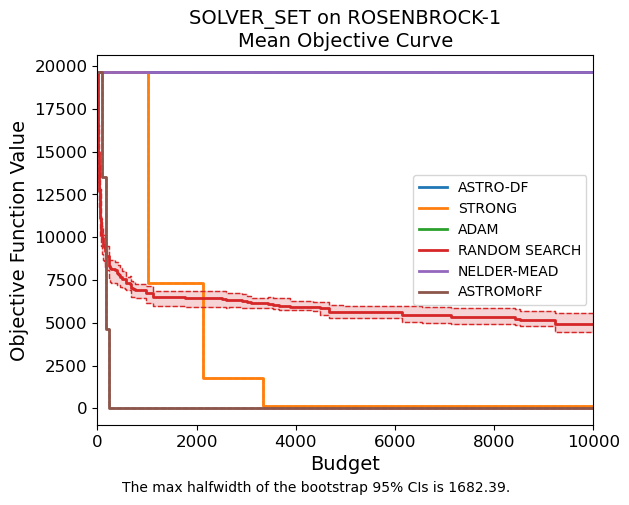

In [28]:
#plot individual plots 
from simopt.experiment_base import plot_progress_curves
#take the experiments from mymetaexperiment and put them into a single list
data_list = [a for x in mymetaexperiment.experiments for a in x]

#sort the data_list into a list of lists where each sublist contains the ProblemSolver instances with the same problem name
sorted_data_list = {}
for ps in data_list:
    problem_name = ps.problem.name
    if problem_name not in sorted_data_list:
        sorted_data_list[problem_name] = [ps]
    else:
        sorted_data_list[problem_name].append(ps)

#create mean plot_progress_curves which has all the ProblemSolver with the same problem name
mean_plots = {}
for problem_name, ps_list in sorted_data_list.items():
    mean_plot = _print_path(
        plot_progress_curves(
            experiments=ps_list, plot_type=PlotType.MEAN, normalize=False
        )
    )
    mean_plots[problem_name] = mean_plot

# for i in range(len(data_list)) :
#     myexperiment = data_list[i]
#     ind_plots = []
#     no_probs = len(problem_abbr_names)
#     for j in range(no_probs) :
#         problem_data = [myexperiment[j]]
#         ind_plot = _print_path(
#             plot_progress_curves(
#                 experiments=problem_data, plot_type=PlotType.ALL, normalize=False
#             )
#         )
#         ind_plots.append(ind_plot)

In [14]:
#Need to have a look at the problem solver DYNAMNEWS repsonse at the initial solution 
import sys
from pathlib import Path

import random 
import numpy as np 
from mrg32k3a.mrg32k3a import MRG32k3a

# Take the current directory, find the parent, and add it to the system path
sys.path.append(str(Path.cwd().parent))

from simopt.experiment_base import instantiate_problem
from simopt.base import Solution

dynamnews_problem = instantiate_problem('DYNAMNEWS-1')
rng_list = [MRG32k3a() for _ in range(dynamnews_problem.model.n_rngs)]
init_sol_x = dynamnews_problem.factors['initial_solution']
init_sol = Solution(init_sol_x, dynamnews_problem)
init_sol.attach_rngs(rng_list)

dynamnews_problem.simulate(init_sol, 10000)

print(f'the response at the initial solution is {init_sol.objectives_mean.item()}')



the response at the initial solution is 120.0


In [15]:
#load in any csv files from /Users/benjaminrees/Desktop/simopt/experiments/WSC_slides_pickle/csv_files that end in '_all_budget_history.csv' or 'all_fn_estimates.csv' and load them into a dictionary where the key is the problem which can be foiund in the file name and the value is the pandas dataframe of the csv file
import os
import pandas as pd
csv_dir = '/Users/benjaminrees/Desktop/WSC_Slides_2/csv_files/'
csv_files = [f for f in os.listdir(csv_dir) if f.endswith('_all_budget_history.csv') or f.endswith('all_fn_estimates.csv')]
csv_data_astrodf = {}
csv_data_astromorf = {}
for file in csv_files:
    file_path = os.path.join(csv_dir, file)
    print(f'Loading file: {file_path}')
    df = pd.read_csv(file_path)
    print(f'Loaded DataFrame with shape: {df.shape}')
    # Extract problem name from file name - the problem name is the found in the file at '_on_{problem_name}_all_budget_history.csv' or '_on_{problem_name}_all_fn_estimates.csv'
    problem_name = file.split('_on_')[1].split('_all_')[0]
    print(f'Extracted problem name: {problem_name}')
    #extract solver name from file name - the solver name is found in the file at '{solver_name}_on_{problem_name}_all_budget_history.csv' or '{solver_name}_on_{problem_name}_all_fn_estimates.csv'
    solver_name = file.split('_on_')[0]
    print(f'Extracted solver name: {solver_name}')
    if solver_name == 'ASTRO-DF':
        csv_data_astrodf[problem_name] = df
    elif solver_name == 'ASTROMoRF':
        csv_data_astromorf[problem_name] = df

Loading file: /Users/benjaminrees/Desktop/WSC_Slides_2/csv_files/ASTRO-DF_on_DYNAMNEWS-1_all_budget_history.csv
Loaded DataFrame with shape: (40, 3)
Extracted problem name: DYNAMNEWS-1
Extracted solver name: ASTRO-DF
Loading file: /Users/benjaminrees/Desktop/WSC_Slides_2/csv_files/ASTROMoRF_on_FACSIZE-1_all_budget_history.csv
Loaded DataFrame with shape: (1390, 3)
Extracted problem name: FACSIZE-1
Extracted solver name: ASTROMoRF
Loading file: /Users/benjaminrees/Desktop/WSC_Slides_2/csv_files/ASTRO-DF_on_FACSIZE-1_all_budget_history.csv
Loaded DataFrame with shape: (4150, 3)
Extracted problem name: FACSIZE-1
Extracted solver name: ASTRO-DF
Loading file: /Users/benjaminrees/Desktop/WSC_Slides_2/csv_files/ASTRO-DF_on_ROSENBROCK-1_all_budget_history.csv
Loaded DataFrame with shape: (4150, 3)
Extracted problem name: ROSENBROCK-1
Extracted solver name: ASTRO-DF
Loading file: /Users/benjaminrees/Desktop/WSC_Slides_2/csv_files/ASTRO-DF_on_CONTAM-2_all_budget_history.csv
Loaded DataFrame with

In [16]:
#check length of each data file
for problem_name, df in csv_data_astrodf.items():
    print(f"ASTRODF data for problem {problem_name} has {len(df)} rows and {len(df.columns)} columns.")

for problem_name, df in csv_data_astromorf.items():
    print(f"ASTROMORF data for problem {problem_name} has {len(df)} rows and {len(df.columns)} columns.")

#check if each data file has any missing values
for problem_name, df in csv_data_astrodf.items():
    if df.isnull().values.any():
        print(f"ASTRODF data for problem {problem_name} has missing values.")
    else:
        print(f"ASTRODF data for problem {problem_name} has no missing values.")

for problem_name, df in csv_data_astromorf.items():
    if df.isnull().values.any():
        print(f"ASTROMORF data for problem {problem_name} has missing values.")
    else:
        print(f"ASTROMORF data for problem {problem_name} has no missing values.")

ASTRODF data for problem DYNAMNEWS-1 has 40 rows and 3 columns.
ASTRODF data for problem FACSIZE-1 has 4150 rows and 3 columns.
ASTRODF data for problem ROSENBROCK-1 has 4150 rows and 3 columns.
ASTRODF data for problem CONTAM-2 has 4150 rows and 3 columns.
ASTRODF data for problem NETWORK-1 has 30 rows and 3 columns.
ASTROMORF data for problem FACSIZE-1 has 1390 rows and 3 columns.
ASTROMORF data for problem ROSENBROCK-1 has 1389 rows and 3 columns.
ASTROMORF data for problem DYNAMNEWS-1 has 1390 rows and 3 columns.
ASTROMORF data for problem CONTAM-2 has 1390 rows and 3 columns.
ASTROMORF data for problem NETWORK-1 has 1384 rows and 3 columns.
ASTRODF data for problem DYNAMNEWS-1 has no missing values.
ASTRODF data for problem FACSIZE-1 has no missing values.
ASTRODF data for problem ROSENBROCK-1 has no missing values.
ASTRODF data for problem CONTAM-2 has no missing values.
ASTRODF data for problem NETWORK-1 has no missing values.
ASTROMORF data for problem FACSIZE-1 has no missing 

In [17]:

minmax: dict[str, int] = {
    'DYNAMNEWS-1': 1, 
    'ROSENBROCK-1': -1,
    'CONTAM-2': -1,
    'NETWORK-1': -1,
    'FACSIZE-1': -1,
}

Loaded ASTRO-DF NETWORK-1: 30 rows, 10 macroreplications
Loaded ASTRO-DF FACSIZE-1: 4150 rows, 10 macroreplications
Loaded ASTRO-DF CONTAM-2: 4150 rows, 10 macroreplications
Loaded ASTRO-DF DYNAMNEWS-1: 40 rows, 10 macroreplications
Loaded ASTRO-DF ROSENBROCK-1: 4150 rows, 10 macroreplications
Loaded ASTROMoRF FACSIZE-1: 1390 rows, 10 macroreplications
Loaded ASTROMoRF ROSENBROCK-1: 1389 rows, 10 macroreplications
Loaded ASTROMoRF DYNAMNEWS-1: 1390 rows, 10 macroreplications
Loaded ASTROMoRF CONTAM-2: 1390 rows, 10 macroreplications
Loaded ASTROMoRF NETWORK-1: 1384 rows, 10 macroreplications
Individual plot saved to 'fn_estimates_CONTAM-2.png'


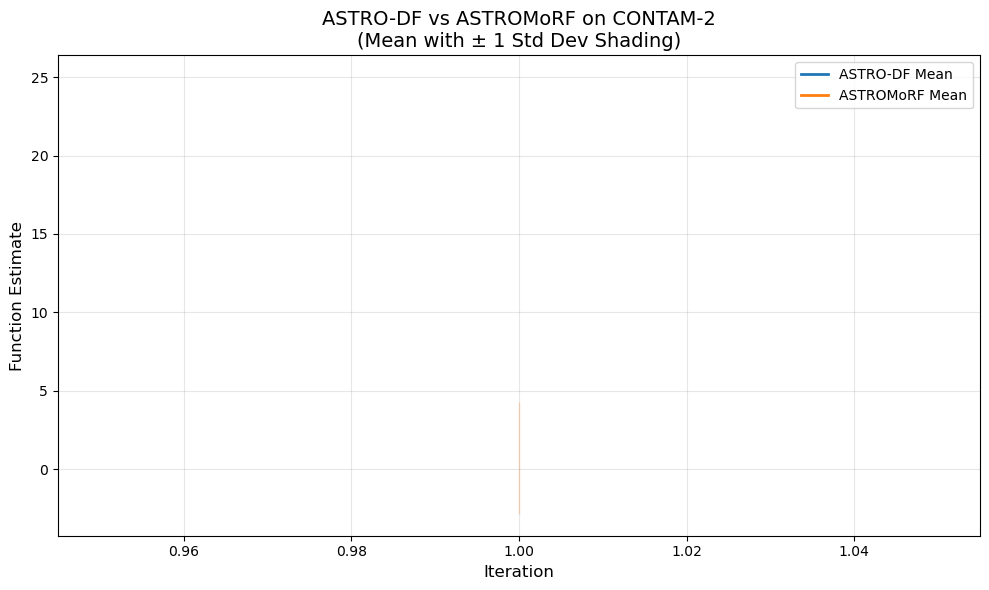

Individual plot saved to 'fn_estimates_DYNAMNEWS-1.png'


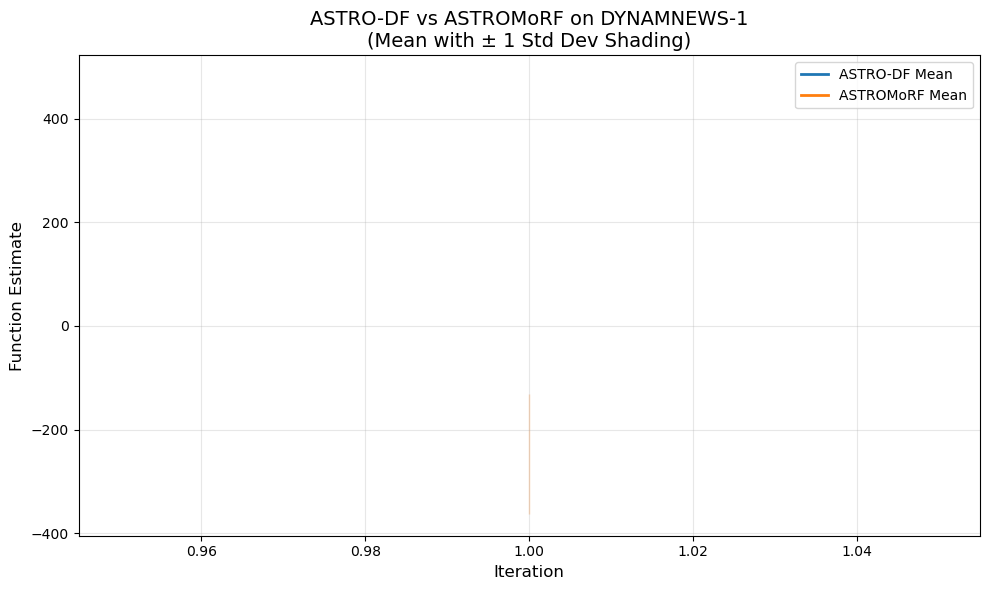

Individual plot saved to 'fn_estimates_FACSIZE-1.png'


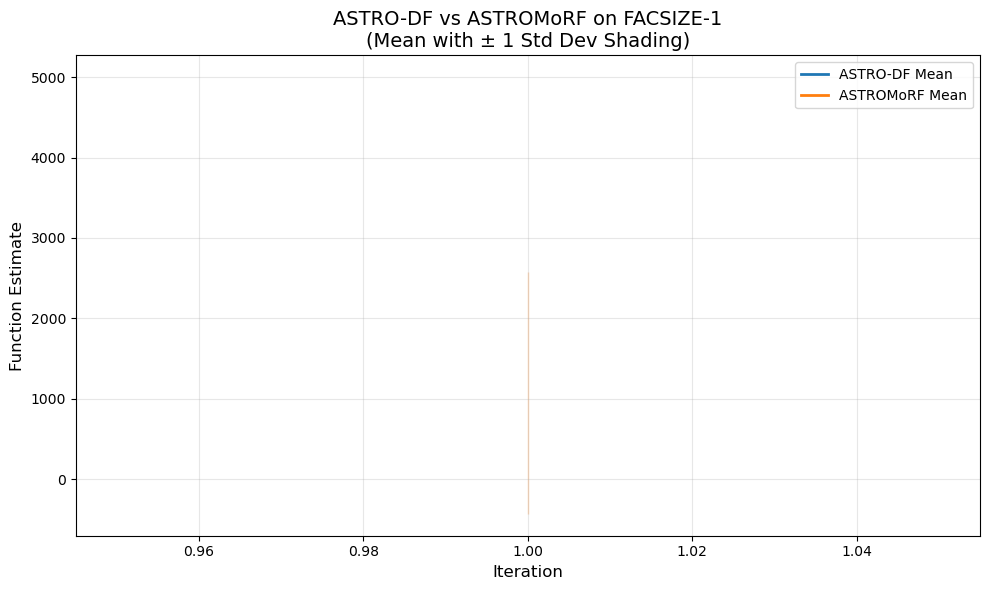

Individual plot saved to 'fn_estimates_NETWORK-1.png'


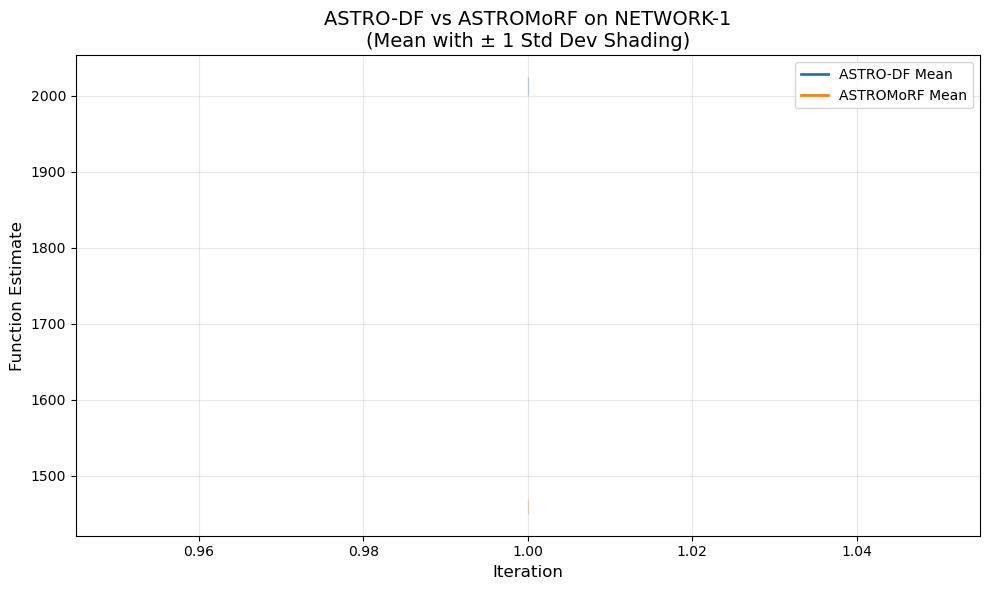

Individual plot saved to 'fn_estimates_ROSENBROCK-1.png'


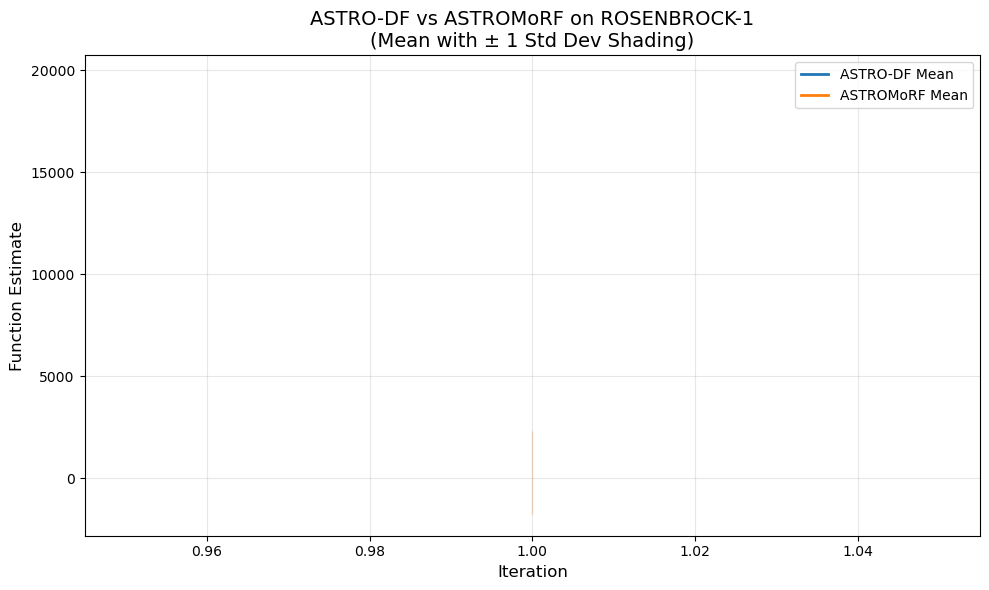

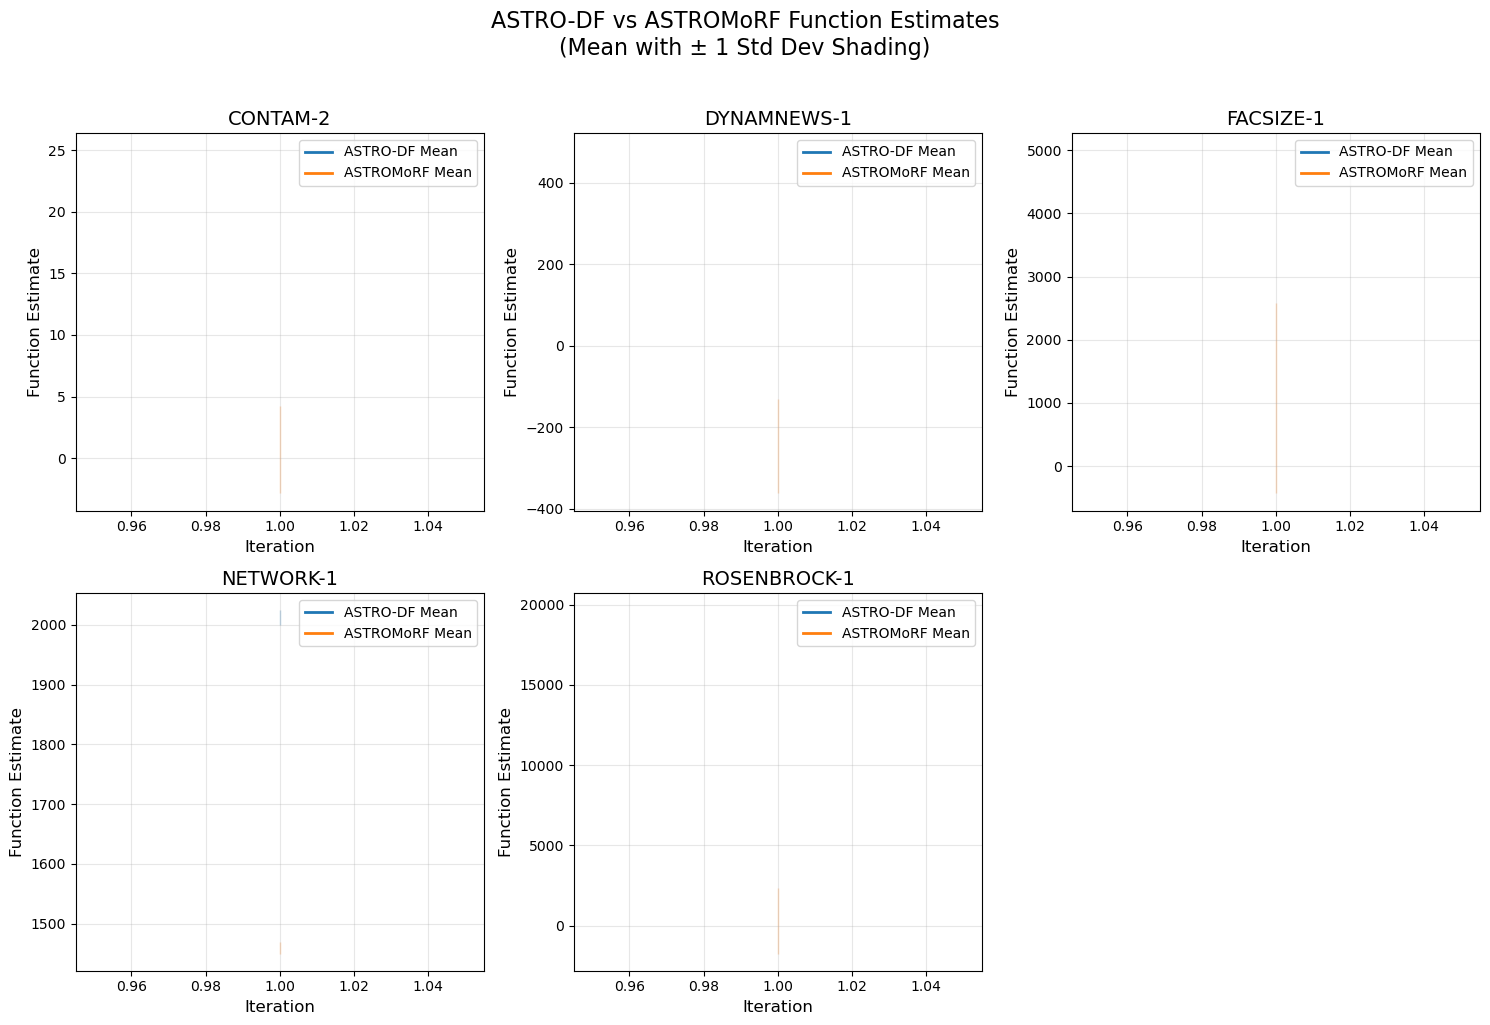


Combined plot saved to 'astrodf_astromorf_function_estimates_combined.png'
Individual plots saved for 5 problems:
  - CONTAM-2: fn_estimates_CONTAM-2.png
  - DYNAMNEWS-1: fn_estimates_DYNAMNEWS-1.png
  - FACSIZE-1: fn_estimates_FACSIZE-1.png
  - NETWORK-1: fn_estimates_NETWORK-1.png
  - ROSENBROCK-1: fn_estimates_ROSENBROCK-1.png


In [19]:
# Plot ASTRO-DF and ASTROMoRF function estimates with mean and variance shading
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Load the function estimate CSV files for both solvers
csv_dir = '/Users/benjaminrees/Desktop/WSC_Slides_2/csv_files/'

# Get all ASTRO-DF function estimate files
astrodf_fn_files = [f for f in os.listdir(csv_dir) if f.startswith('ASTRO-DF') and f.endswith('_all_function_estimates.csv')]
astromorf_fn_files = [f for f in os.listdir(csv_dir) if f.startswith('ASTROMoRF') and f.endswith('_all_function_estimates.csv')]

# Load ASTRO-DF data
astrodf_fn_data = {}
for file in astrodf_fn_files:
    file_path = os.path.join(csv_dir, file)
    df = pd.read_csv(file_path)
    problem_name = file.split('_on_')[1].split('_all_')[0]
    astrodf_fn_data[problem_name] = df
    print(f"Loaded ASTRO-DF {problem_name}: {len(df)} rows, {df['Macroreplication'].nunique()} macroreplications")

# Load ASTROMoRF data
astromorf_fn_data = {}
for file in astromorf_fn_files:
    file_path = os.path.join(csv_dir, file)
    df = pd.read_csv(file_path)
    problem_name = file.split('_on_')[1].split('_all_')[0]
    astromorf_fn_data[problem_name] = df
    print(f"Loaded ASTROMoRF {problem_name}: {len(df)} rows, {df['Macroreplication'].nunique()} macroreplications")

# Get all unique problem names
all_problems = sorted(set(astrodf_fn_data.keys()) | set(astromorf_fn_data.keys()))
n_problems = len(all_problems)

# Define colors for each solver
astrodf_color = '#1f77b4'  # Blue
astromorf_color = '#ff7f0e'  # Orange

def get_max_iteration_for_problem(problem_name, astrodf_fn_data, astromorf_fn_data):
    """Get the minimum max iteration between the two solvers for a problem."""
    max_iters = []
    if problem_name in astrodf_fn_data:
        max_iters.append(astrodf_fn_data[problem_name]['Iteration'].max())
    if problem_name in astromorf_fn_data:
        max_iters.append(astromorf_fn_data[problem_name]['Iteration'].max())
    
    if max_iters:
        return min(max_iters)  # Return the minimum of the two max iterations
    return None

def plot_solver_comparison(ax, problem_name, astrodf_fn_data, astromorf_fn_data, astrodf_color, astromorf_color, minmax):
    """Helper function to plot both solvers on a single axis."""
    # Get the x-axis limit (minimum of the two solvers' max iterations)
    x_max = get_max_iteration_for_problem(problem_name, astrodf_fn_data, astromorf_fn_data)
    
    # Get the multiplier for this problem (-1 * minmax[problem])
    multiplier = -1 * minmax.get(problem_name, 1)
    
    # Plot ASTRO-DF if available
    if problem_name in astrodf_fn_data:
        df = astrodf_fn_data[problem_name].copy()
        # Apply the multiplier to function estimates
        df['FunctionEstimate'] = df['FunctionEstimate'] * multiplier
        # Filter to only include iterations up to x_max
        df_filtered = df[df['Iteration'] <= x_max]
        grouped = df_filtered.groupby('Iteration')['FunctionEstimate'].agg(['mean', 'std', 'count'])
        
        iterations = grouped.index.values
        mean_values = grouped['mean'].values
        std_values = grouped['std'].fillna(0).values
        
        ax.plot(iterations, mean_values, color=astrodf_color, linewidth=2, label='ASTRO-DF Mean')
        ax.fill_between(iterations, 
                        mean_values - std_values, 
                        mean_values + std_values, 
                        alpha=0.3, 
                        color=astrodf_color)
    
    # Plot ASTROMoRF if available
    if problem_name in astromorf_fn_data:
        df = astromorf_fn_data[problem_name].copy()
        # Apply the multiplier to function estimates
        df['FunctionEstimate'] = df['FunctionEstimate'] * multiplier
        # Filter to only include iterations up to x_max
        df_filtered = df[df['Iteration'] <= x_max]
        grouped = df_filtered.groupby('Iteration')['FunctionEstimate'].agg(['mean', 'std', 'count'])
        
        iterations = grouped.index.values
        mean_values = grouped['mean'].values
        std_values = grouped['std'].fillna(0).values
        
        ax.plot(iterations, mean_values, color=astromorf_color, linewidth=2, label='ASTROMoRF Mean')
        ax.fill_between(iterations, 
                        mean_values - std_values, 
                        mean_values + std_values, 
                        alpha=0.3, 
                        color=astromorf_color)
    
    # Set x-axis limit 
    #! Comment this out to not show relative iterations
    # if x_max is not None:
    #     ax.set_xlim(0, x_max)
    
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Function Estimate', fontsize=12)
    ax.set_title(f'{problem_name}', fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# ============================================
# 1. Create individual plots for each problem
# ============================================
individual_plot_paths = {}
for problem_name in all_problems:
    fig_ind, ax_ind = plt.subplots(figsize=(10, 6))
    
    plot_solver_comparison(ax_ind, problem_name, astrodf_fn_data, astromorf_fn_data, astrodf_color, astromorf_color, minmax)
    
    ax_ind.set_title(f'ASTRO-DF vs ASTROMoRF on {problem_name}\n(Mean with ± 1 Std Dev Shading)', fontsize=14)
    
    plt.tight_layout()
    
    # Save individual plot
    individual_path = f'fn_estimates_{problem_name}.png'
    plt.savefig(individual_path, dpi=150, bbox_inches='tight')
    individual_plot_paths[problem_name] = individual_path
    print(f"Individual plot saved to '{individual_path}'")
    
    plt.show()

# ============================================
# 2. Create combined subplot figure
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, problem_name in enumerate(all_problems):
    ax = axes[idx]
    plot_solver_comparison(ax, problem_name, astrodf_fn_data, astromorf_fn_data, astrodf_color, astromorf_color, minmax)

# Hide unused subplots
for idx in range(n_problems, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ASTRO-DF vs ASTROMoRF Function Estimates\n(Mean with ± 1 Std Dev Shading)', fontsize=16, y=1.02)
plt.tight_layout()

plt.savefig('astrodf_astromorf_function_estimates_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("Combined plot saved to 'astrodf_astromorf_function_estimates_combined.png'")
print(f"Individual plots saved for {len(individual_plot_paths)} problems:")
for problem, path in individual_plot_paths.items():
    print(f"  - {problem}: {path}")

Loaded ASTRO-DF DYNAMNEWS-1: 40 rows, 10 macroreplications
Loaded ASTRO-DF FACSIZE-1: 4150 rows, 10 macroreplications
Loaded ASTRO-DF ROSENBROCK-1: 4150 rows, 10 macroreplications
Loaded ASTRO-DF CONTAM-2: 4150 rows, 10 macroreplications
Loaded ASTRO-DF NETWORK-1: 22 rows, 10 macroreplications
Loaded ASTROMoRF FACSIZE-1: 1030 rows, 10 macroreplications
Loaded ASTROMoRF ROSENBROCK-1: 223 rows, 10 macroreplications
Loaded ASTROMoRF DYNAMNEWS-1: 2070 rows, 10 macroreplications
Loaded ASTROMoRF CONTAM-2: 2060 rows, 10 macroreplications
Loaded ASTROMoRF NETWORK-1: 272 rows, 10 macroreplications
Individual plot saved to 'budget_history_CONTAM-2.png'


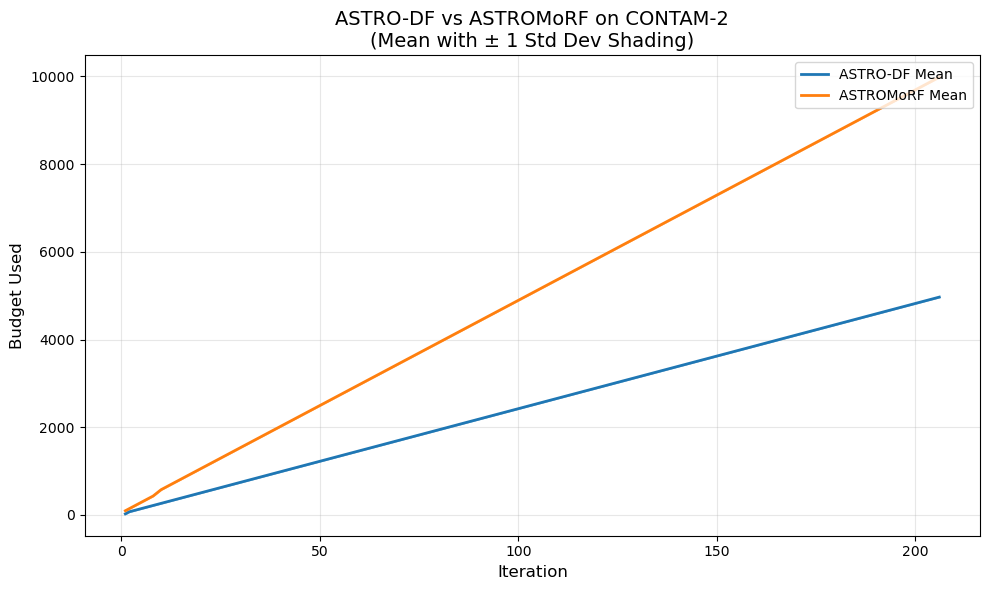

Individual plot saved to 'budget_history_DYNAMNEWS-1.png'


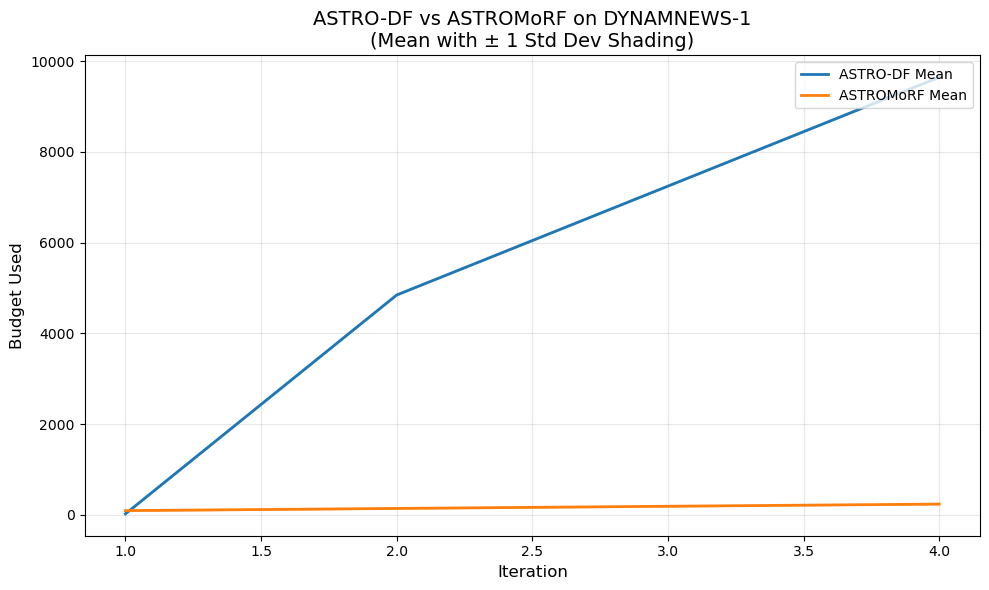

Individual plot saved to 'budget_history_FACSIZE-1.png'


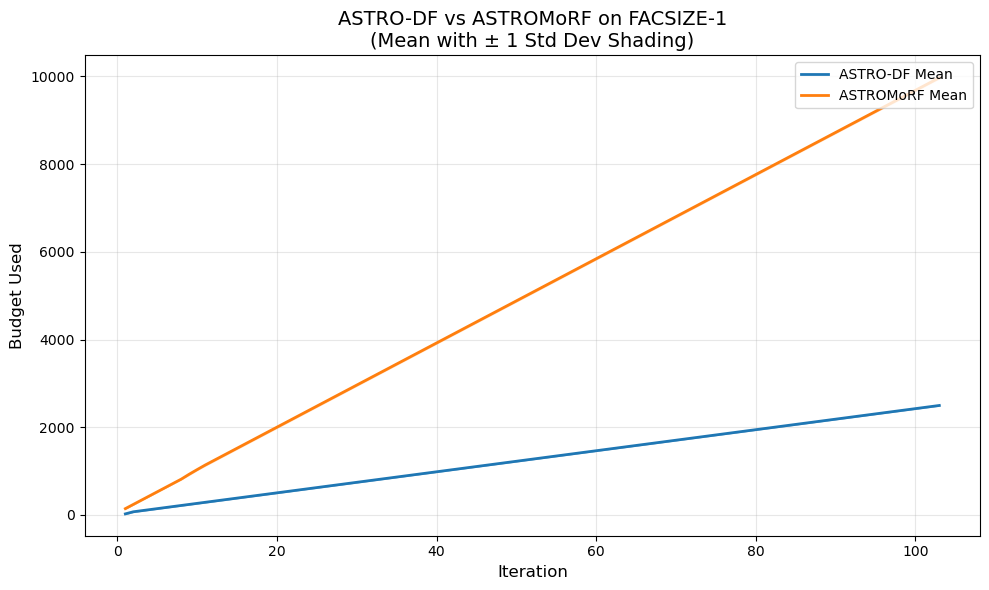

Individual plot saved to 'budget_history_NETWORK-1.png'


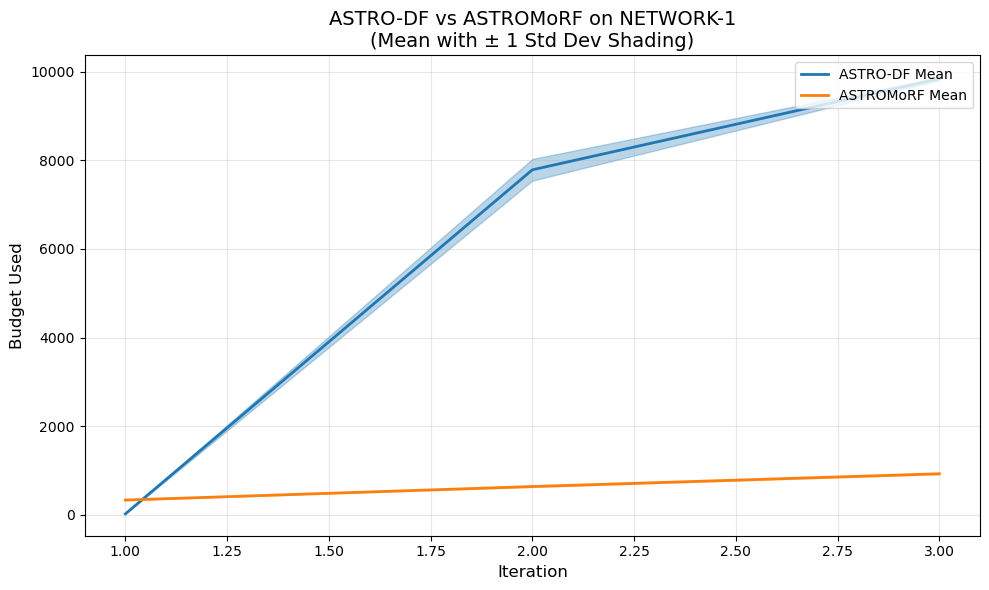

Individual plot saved to 'budget_history_ROSENBROCK-1.png'


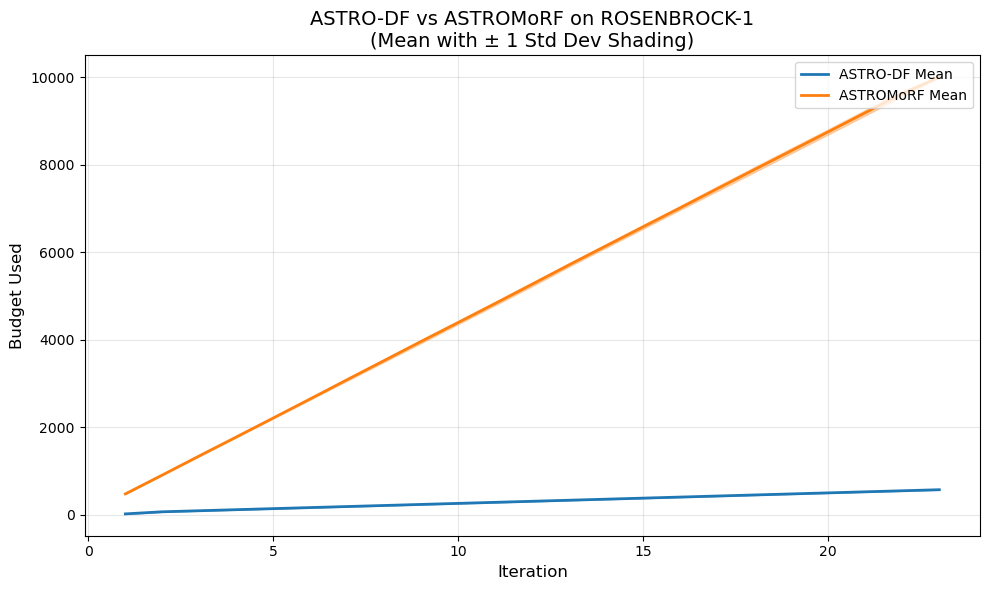

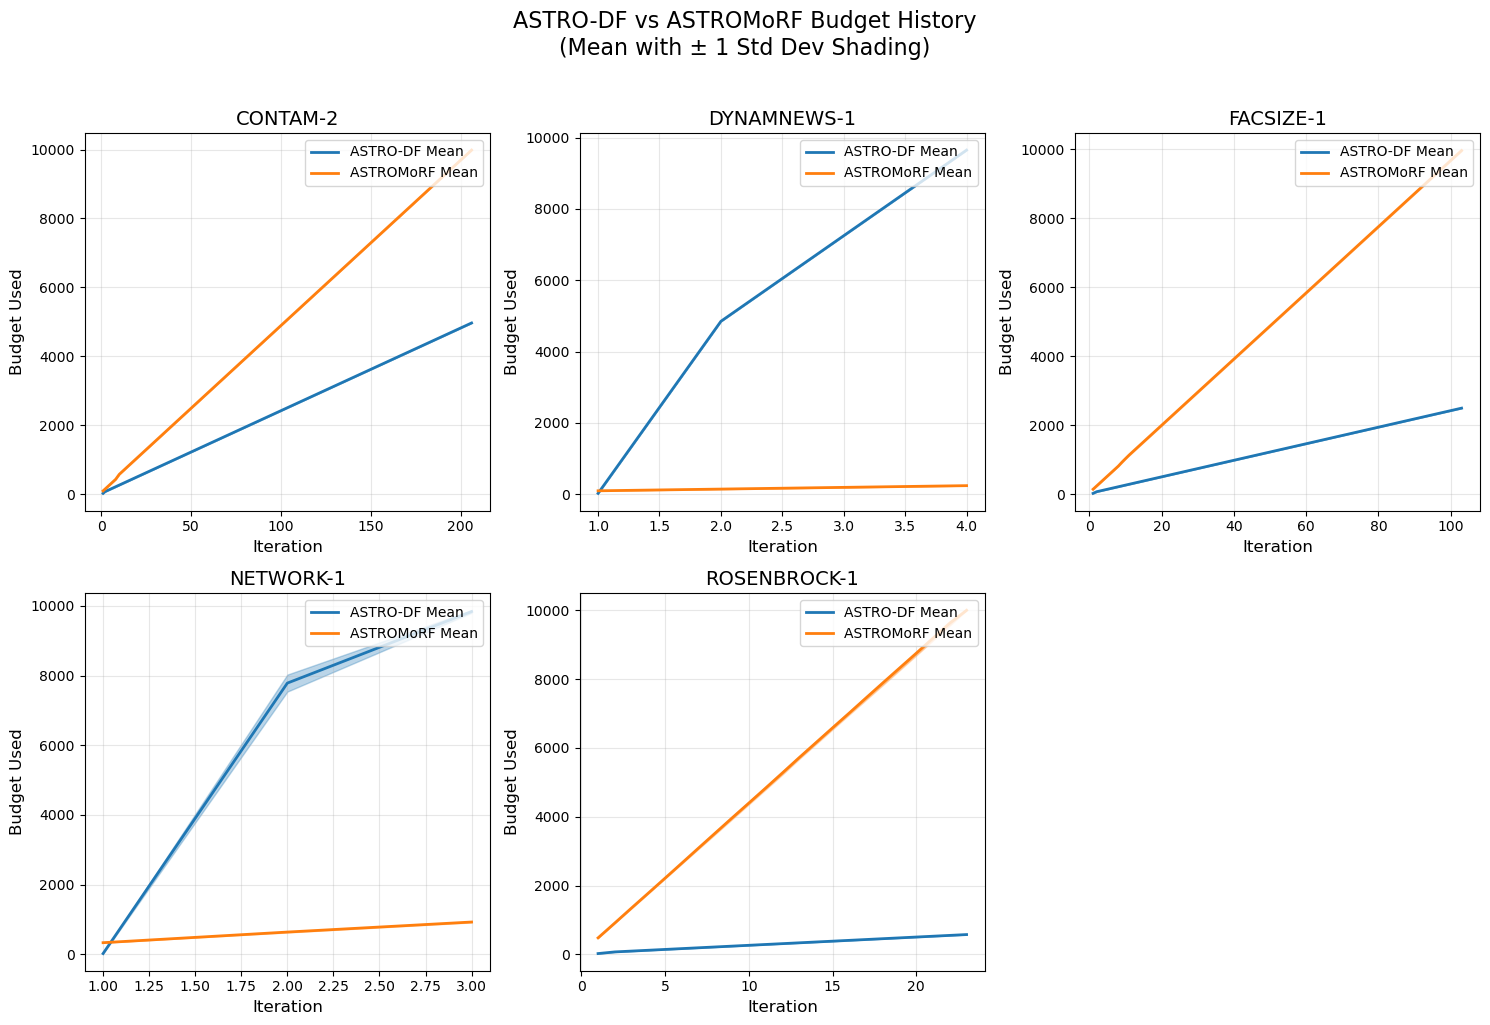


Combined plot saved to 'astrodf_astromorf_budget_history_combined.png'
Individual plots saved for 5 problems:
  - CONTAM-2: budget_history_CONTAM-2.png
  - DYNAMNEWS-1: budget_history_DYNAMNEWS-1.png
  - FACSIZE-1: budget_history_FACSIZE-1.png
  - NETWORK-1: budget_history_NETWORK-1.png
  - ROSENBROCK-1: budget_history_ROSENBROCK-1.png


In [33]:
# Plot ASTRO-DF and ASTROMoRF function estimates with mean and variance shading
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Load the function estimate CSV files for both solvers
csv_dir = '/Users/benjaminrees/Desktop/simopt/experiments/WSC_slides_pickle/csv_files/'

# Get all ASTRO-DF function estimate files
astrodf_fn_files = [f for f in os.listdir(csv_dir) if f.startswith('ASTRO-DF') and f.endswith('_all_budget_history.csv')]
astromorf_fn_files = [f for f in os.listdir(csv_dir) if f.startswith('ASTROMoRF') and f.endswith('_all_budget_history.csv')]

# Load ASTRO-DF data
astrodf_fn_data = {}
for file in astrodf_fn_files:
    file_path = os.path.join(csv_dir, file)
    df = pd.read_csv(file_path)
    problem_name = file.split('_on_')[1].split('_all_')[0]
    astrodf_fn_data[problem_name] = df
    print(f"Loaded ASTRO-DF {problem_name}: {len(df)} rows, {df['Macroreplication'].nunique()} macroreplications")

# Load ASTROMoRF data
astromorf_fn_data = {}
for file in astromorf_fn_files:
    file_path = os.path.join(csv_dir, file)
    df = pd.read_csv(file_path)
    problem_name = file.split('_on_')[1].split('_all_')[0]
    astromorf_fn_data[problem_name] = df
    print(f"Loaded ASTROMoRF {problem_name}: {len(df)} rows, {df['Macroreplication'].nunique()} macroreplications")

# Get all unique problem names
all_problems = sorted(set(astrodf_fn_data.keys()) | set(astromorf_fn_data.keys()))
n_problems = len(all_problems)

# Define colors for each solver
astrodf_color = '#1f77b4'  # Blue
astromorf_color = '#ff7f0e'  # Orange

def get_max_iteration_for_problem(problem_name, astrodf_fn_data, astromorf_fn_data):
    """Get the minimum max iteration between the two solvers for a problem."""
    max_iters = []
    if problem_name in astrodf_fn_data:
        max_iters.append(astrodf_fn_data[problem_name]['Iteration'].max())
    if problem_name in astromorf_fn_data:
        max_iters.append(astromorf_fn_data[problem_name]['Iteration'].max())
    
    if max_iters:
        return min(max_iters)  # Return the minimum of the two max iterations
    return None

def plot_solver_comparison(ax, problem_name, astrodf_fn_data, astromorf_fn_data, astrodf_color, astromorf_color, minmax):
    """Helper function to plot both solvers on a single axis."""
    # Get the x-axis limit (minimum of the two solvers' max iterations)
    x_max = get_max_iteration_for_problem(problem_name, astrodf_fn_data, astromorf_fn_data)
    
    
    # Plot ASTRO-DF if available
    if problem_name in astrodf_fn_data:
        df = astrodf_fn_data[problem_name].copy()
        # Apply the multiplier to function estimates
        df['FunctionEstimate'] = df['FunctionEstimate']
        # Filter to only include iterations up to x_max
        df_filtered = df[df['Iteration'] <= x_max]
        grouped = df_filtered.groupby('Iteration')['FunctionEstimate'].agg(['mean', 'std', 'count'])
        
        iterations = grouped.index.values
        mean_values = grouped['mean'].values
        std_values = grouped['std'].fillna(0).values
        
        ax.plot(iterations, mean_values, color=astrodf_color, linewidth=2, label='ASTRO-DF Mean')
        ax.fill_between(iterations, 
                        mean_values - std_values, 
                        mean_values + std_values, 
                        alpha=0.3, 
                        color=astrodf_color)
    
    # Plot ASTROMoRF if available
    if problem_name in astromorf_fn_data:
        df = astromorf_fn_data[problem_name].copy()
        # Apply the multiplier to function estimates
        df['FunctionEstimate'] = df['FunctionEstimate'] 
        # Filter to only include iterations up to x_max
        df_filtered = df[df['Iteration'] <= x_max]
        grouped = df_filtered.groupby('Iteration')['FunctionEstimate'].agg(['mean', 'std', 'count'])
        
        iterations = grouped.index.values
        mean_values = grouped['mean'].values
        std_values = grouped['std'].fillna(0).values
        
        ax.plot(iterations, mean_values, color=astromorf_color, linewidth=2, label='ASTROMoRF Mean')
        ax.fill_between(iterations, 
                        mean_values - std_values, 
                        mean_values + std_values, 
                        alpha=0.3, 
                        color=astromorf_color)
    
    # Set x-axis limit 
    #! Comment this out to not show relative iterations
    # if x_max is not None:
    #     ax.set_xlim(0, x_max)
    
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Budget Used', fontsize=12)
    ax.set_title(f'{problem_name}', fontsize=14)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# ============================================
# 1. Create individual plots for each problem
# ============================================
individual_plot_paths = {}
for problem_name in all_problems:
    fig_ind, ax_ind = plt.subplots(figsize=(10, 6))
    
    plot_solver_comparison(ax_ind, problem_name, astrodf_fn_data, astromorf_fn_data, astrodf_color, astromorf_color, minmax)
    
    ax_ind.set_title(f'ASTRO-DF vs ASTROMoRF on {problem_name}\n(Mean with ± 1 Std Dev Shading)', fontsize=14)
    
    plt.tight_layout()
    
    # Save individual plot
    individual_path = f'budget_history_{problem_name}.png'
    plt.savefig(individual_path, dpi=150, bbox_inches='tight')
    individual_plot_paths[problem_name] = individual_path
    print(f"Individual plot saved to '{individual_path}'")
    
    plt.show()

# ============================================
# 2. Create combined subplot figure
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, problem_name in enumerate(all_problems):
    ax = axes[idx]
    plot_solver_comparison(ax, problem_name, astrodf_fn_data, astromorf_fn_data, astrodf_color, astromorf_color, minmax)

# Hide unused subplots
for idx in range(n_problems, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('ASTRO-DF vs ASTROMoRF Budget History\n(Mean with ± 1 Std Dev Shading)', fontsize=16, y=1.02)
plt.tight_layout()

plt.savefig('astrodf_astromorf_budget_history_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("Combined plot saved to 'astrodf_astromorf_budget_history_combined.png'")
print(f"Individual plots saved for {len(individual_plot_paths)} problems:")
for problem, path in individual_plot_paths.items():
    print(f"  - {problem}: {path}")
